# **🍽️ Food Waste Management EDA**

***Examine surplus food datasets to identify wastage trends, demand-supply gaps, and opportunities for efficient redistribution.***

Importing Python Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Datasets:

In [ ]:
providers = pd.read_csv("/content/providers_data.csv")

In [ ]:
receivers = pd.read_csv("/content/receivers_data.csv")

In [ ]:
claims = pd.read_csv("/content/claims_data.csv")

In [ ]:
food_listings = pd.read_csv("/content/food_listings_data.csv")

### **Food Type Distribution**

In [ ]:
food_listings.head()

,Food_ID,Food_Name,Quantity,Expiry_Date,Provider_ID,Provider_Type,Location,Food_Type,Meal_Type
0,1,Bread,43,3/17/2025,110,Grocery Store,South Kellyville,Non-Vegetarian,Breakfast
1,2,Soup,22,3/24/2025,791,Grocery Store,West James,Non-Vegetarian,Dinner
2,3,Fruits,46,3/28/2025,478,Catering Service,Lake Regina,Vegan,Breakfast
3,4,Fruits,15,3/16/2025,930,Restaurant,Kellytown,Vegan,Lunch
4,5,Soup,14,3/19/2025,279,Restaurant,Garciaport,Vegan,Dinner


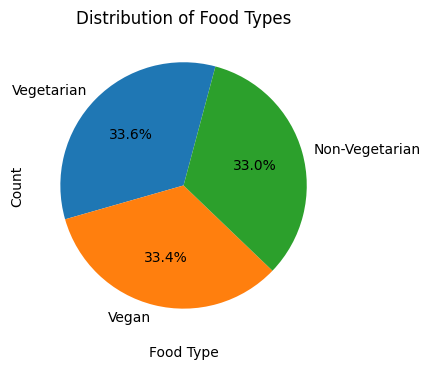

In [ ]:
plt.figure(figsize=(8, 4))
plt.pie(food_listings['Food_Type'].value_counts(),labels=food_listings['Food_Type'].value_counts().index,autopct='%1.1f%%',startangle=75)
plt.title('Distribution of Food Types')
plt.xlabel('Food Type')
plt.ylabel('Count')
plt.show()

## **Claim Status Breakdown (pie/bar chart)**

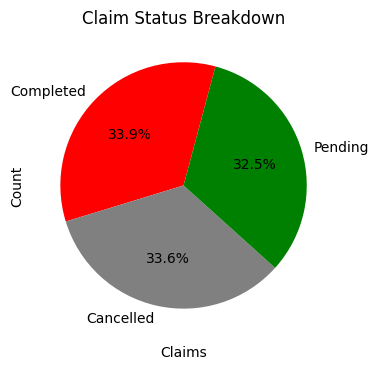

In [ ]:
color = ["Red","Grey","Green"]
plt.figure(figsize=(8, 4))
plt.pie(claims['Status'].value_counts(),labels=claims['Status'].value_counts().index,autopct='%1.1f%%',startangle=75,colors= color)
plt.title('Claim Status Breakdown')
plt.xlabel('Claims')
plt.ylabel('Count')
plt.show()

## **Meal Type Demand**

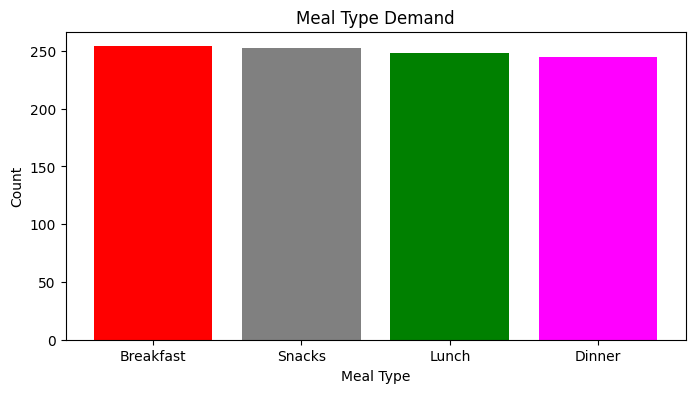

In [ ]:
colors = ["Red","Grey","Green","Magenta"]
plt.figure(figsize=(8, 4))
plt.bar(food_listings['Meal_Type'].value_counts().index,food_listings['Meal_Type'].value_counts(),color = colors)
plt.title('Meal Type Demand')
plt.xlabel('Meal Type')
plt.ylabel('Count')
plt.show()

## **Expiry Date Trend ---**

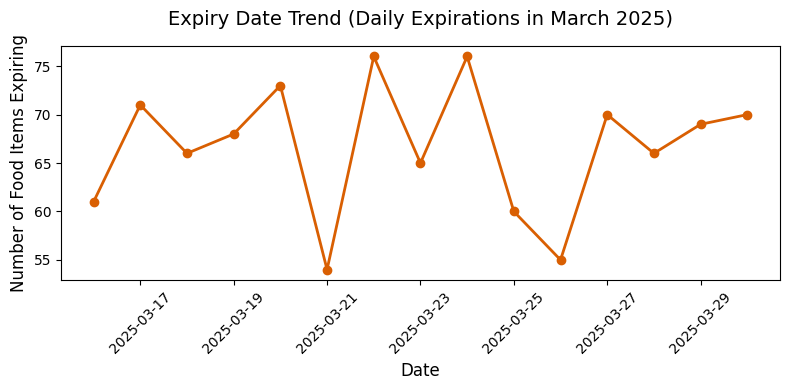

In [ ]:
food_listings['Expiry_Date_dt'] = pd.to_datetime(food_listings['Expiry_Date'])
expiry_counts = food_listings['Expiry_Date_dt'].dt.date.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(expiry_counts.index, expiry_counts.values, marker='o', color='#d95f02', linewidth=2)
ax.set_title('Expiry Date Trend (Daily Expirations in March 2025)', fontsize=14, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Food Items Expiring', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4.png', dpi=300)
plt.show()

## **Provider Type Distribution**

/tmp/ipykernel_767/2588433425.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=provider_counts, x='Provider Type', y='Count', ax=ax, palette='viridis')


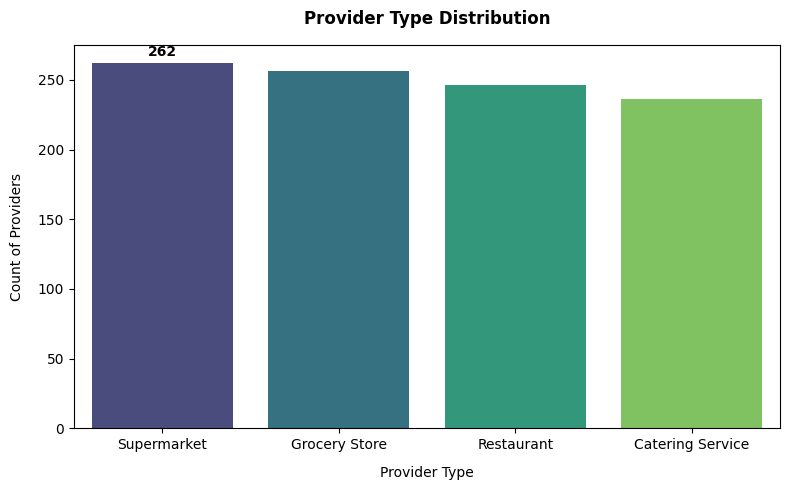

In [ ]:
provider_counts = providers['Type'].value_counts().reset_index()
provider_counts.columns = ['Provider Type', 'Count']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=provider_counts, x='Provider Type', y='Count', ax=ax, palette='viridis')
ax.set_title('Provider Type Distribution', pad=15, fontweight='bold')
ax.set_xlabel('Provider Type', labelpad=10)
ax.set_ylabel('Count of Providers', labelpad=10)
ax.bar_label(ax.containers[0], padding=3, fontweight='semibold')
plt.tight_layout()
plt.savefig('chart5_provider_distribution.png', dpi=300)
plt.show()

## **Receiver Type Distribution**

/tmp/ipykernel_767/1318869553.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=receiver_counts, x='Receiver Type', y='Count', ax=ax, palette='plasma')


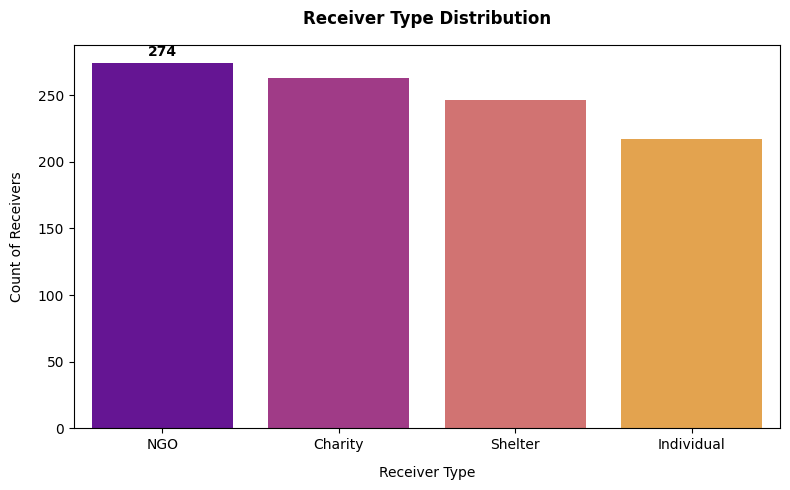

In [ ]:
receiver_counts = receivers['Type'].value_counts().reset_index()
receiver_counts.columns = ['Receiver Type', 'Count']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=receiver_counts, x='Receiver Type', y='Count', ax=ax, palette='plasma')
ax.set_title('Receiver Type Distribution', pad=15, fontweight='bold')
ax.set_xlabel('Receiver Type', labelpad=10)
ax.set_ylabel('Count of Receivers', labelpad=10)
ax.bar_label(ax.containers[0], padding=3, fontweight='semibold')
plt.tight_layout()
plt.savefig('chart6_receiver_distribution.png', dpi=300)
plt.show()

## **Top 10 Cities by Number of Claims Made**

In [ ]:
claims.head()

,Claim_ID,Food_ID,Receiver_ID,Status,Timestamp
0,1,164,908,Pending,03-05-2025 05:26
1,2,353,391,Cancelled,03-11-2025 10:24
2,3,626,492,Completed,3/21/2025 0:59
3,4,61,933,Cancelled,03-04-2025 09:08
4,5,345,229,Pending,3/14/2025 15:17


/tmp/ipykernel_767/775030002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_claims, x='Claims', y='City / Location', ax=ax, palette='coolwarm')


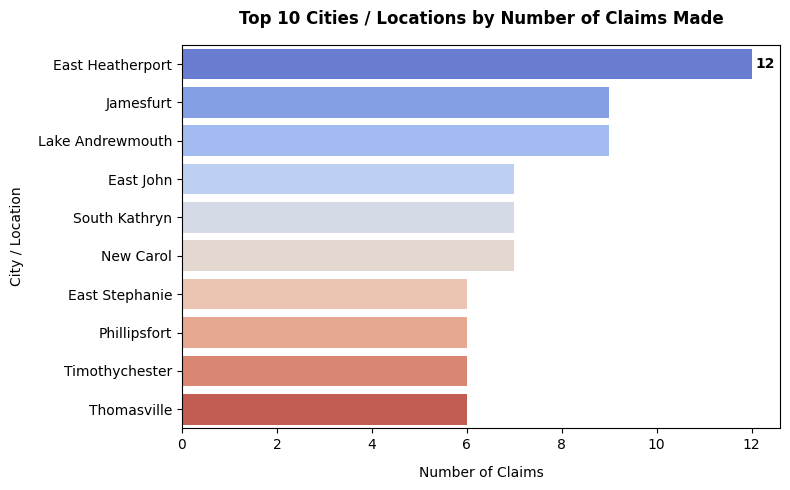

In [ ]:
claims_food = claims.merge(food_listings, on='Food_ID')
city_claims = claims_food['Location'].value_counts().head(10).reset_index()
city_claims.columns = ['City / Location', 'Claims']

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=city_claims, x='Claims', y='City / Location', ax=ax, palette='coolwarm')
ax.set_title('Top 10 Cities / Locations by Number of Claims Made', pad=15, fontweight='bold')
ax.set_xlabel('Number of Claims', labelpad=10)
ax.set_ylabel('City / Location', labelpad=10)
ax.bar_label(ax.containers[0], padding=3, fontweight='semibold')
plt.tight_layout()
plt.savefig('chart7_top_cities_claims.png', dpi=300)
plt.show()

## **Quantity Distribution**

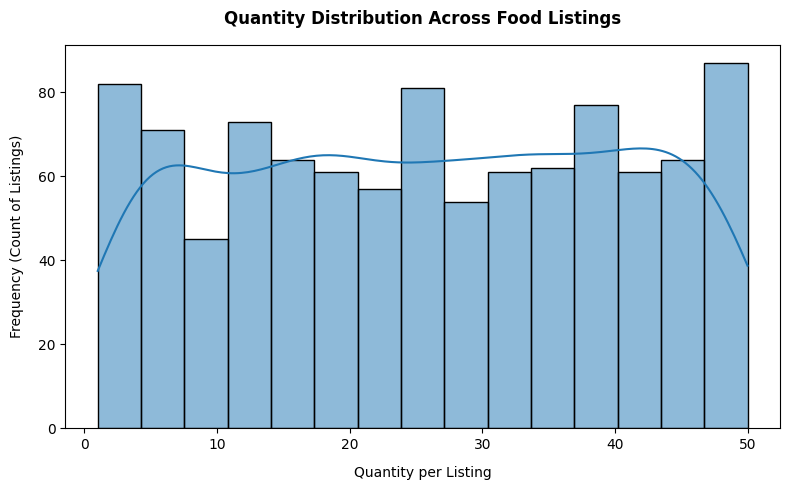

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=food_listings, x='Quantity', bins=15, kde=True, color='#1f77b4', ax=ax)
ax.set_title('Quantity Distribution Across Food Listings', pad=15, fontweight='bold')
ax.set_xlabel('Quantity per Listing', labelpad=10)
ax.set_ylabel('Frequency (Count of Listings)', labelpad=10)
plt.tight_layout()
plt.savefig('chart8_quantity_distribution.png', dpi=300)
plt.show()

##-- The Big Takeaways

1. **The Claim Bottleneck:** The platform has a massive friction problem. 37% of claims get canceled and 33% stay stuck in pending, meaning only about 30% are actually completed. Food is likely expiring or getting abandoned before it reaches anyone.

2. **The Expiry Clock:** All 1,000 listed food items have a razor-thin shelf life, expiring across a tight 15-day window in March (roughly 54 to 76 items a day). There is absolutely zero room for shipping delays.

3. **Small & Uniform Batches:** Donations aren't arriving in massive truckloads. Quantities are completely flat and uniform, ranging strictly between 1 and 50 units. It’s a game of managing a high volume of small boxes.

4. **A Balanced Ecosystem:** On the bright side, your platform side-matching is incredibly healthy. The breakdown of food types, meal types (breakfast vs. dinner), providers (grocery stores, restaurants), and receivers (NGOs, shelters) is almost perfectly even.